# Penalty sensitivity analysis

## Imports and paths

In [1]:
import pandas as pd
from matplotlib import pyplot as plt
import os
import sys
import numpy as np

In [2]:
current_path = os.getcwd()
cwd = os.path.dirname(current_path)
sys.path.append(os.path.join(cwd, "utilities"))

# Import pickle operations

from pickle_file_operations import read_pickle, write_pickle
from optimization_dataclasses import Optimization_Results
# pd.set_option('display.float_format', '{:.4f}'.format)

In [3]:
def saturation_func(df):
    x = df["flexibility_MWh"]
    y = df["updated_max_flexibility_MWh"]
    a = df["shaping_parameters"][0]
    b = df["shaping_parameters"][1]

    x_new = max(0.098, x)
    y_new = max(0.10, y)
    if y_new / x_new > 1:
        z = (-1 * b) ** -1 * x_new * ((np.log((y_new / x_new) - 1)) - a)
    else:
        x_new = 0.99 * y_new
        z = (-1 * b) ** -1 * x_new * ((np.log((y_new / x_new) - 1)) - a)
        
    z_positive = max(z, 0)
    return round(z_positive, 3)

In [4]:
def calculate_revenue(optimization_results: Optimization_Results): 

    df = optimization_results.decision_variables
    df["actual_flexibility_cost_DKK"] = df.apply(saturation_func, axis=1)
    df["net_revenue"] = df.market_price * df.flexibility_MWh - df.actual_flexibility_cost_DKK
    df["square_error"] = (df["actual_flexibility_cost_DKK"] - df["flexibility_cost_DKK"]) ** 2

    return df

def results_summary(optimization_results: Optimization_Results): 

    df = optimization_results.decision_variables
    solve_check = 100 * round(optimization_results.mip_gap, 3) <= 1.0
    
    summary_dict = {"objective_value": df.net_revenue.sum(),
                    "mean_square_error": df.square_error.mean(),
                    "runtime": optimization_results.runtime, 
                    "cpu_time": optimization_results.cpu_time, 
                    "mip_gap": 100 * round(optimization_results.mip_gap, 3), 
                    "solve_check": solve_check}
    return pd.DataFrame(summary_dict, index=[0])

def identify_best_case(df: pd.DataFrame):

    max_objective_value = df['objective_value'].max()
    
    # Step 2: Filter rows with the maximum objective value
    best_objective_cases = df[df['objective_value'] == max_objective_value]
    
    # Step 3: Among the filtered rows, find the row with the minimum solve time
    best_case = best_objective_cases.loc[best_objective_cases['runtime'].idxmin()]
    
    return best_case

In [5]:
results_path = os.path.join(cwd, "length results")
folders = ["PCTAR", "PCAR"]
summary_cols = ["objective_value", "mean_square_error", "runtime", "cpu_time", "mip_gap", "solve_check", 
                "length", "methodology", "scenario_type", "case", "weights", "alpha"]

In [6]:
%%time
summary_tables = pd.DataFrame(columns = summary_cols)
for folder in folders:
    filepath = os.path.join(results_path, folder)
    for filename in list(os.listdir(filepath)):
        file_path = os.path.join(filepath, filename)
        length = filename.split("_")[0]
        data = read_pickle(file_path)
        for scenario, scenario_results in list(data.items()):
            for case, results in list(scenario_results.items()):
                for weights, alphas_result in list(results.items()):
                    for alpha, result_object in list(alphas_result.items()):
                        if alpha == 1:
                            result_object.decision_variables = calculate_revenue(result_object)
                            result_row = results_summary(result_object)
                            result_row[summary_cols[-6:-2]] = [length, folder, scenario, case]
                            result_row["weights"] = [weights] 
                            result_row["alpha"] = alpha
                            summary_tables.loc[len(summary_tables)] = result_row.values[0]
        # write_pickle(data, os.path.join(filepath, "Results_with_revenue.pickle"))

CPU times: total: 4.02 s
Wall time: 4.17 s


In [7]:
best_cases = []
for key, df in list(summary_tables.groupby(["length", "methodology", "scenario_type", "case"])):
    best_case = identify_best_case(df)
    best_cases.append(best_case)

In [8]:
best_cases_df = pd.concat(best_cases, axis = 1).transpose().reset_index(drop=True)

In [9]:
best_cases_df

,objective_value,mean_square_error,runtime,cpu_time,mip_gap,solve_check,length,methodology,scenario_type,case,weights,alpha
0,-442.775984,3.871636,0.0,0.0,0,True,1,PCAR,Low_prices,0,"(1000, 0)",1
1,-87.826216,9.650862,0.019,0.016,0,True,1,PCAR,Low_prices,1,"(1000, 0)",1
2,-128.117724,9.752329,0.012,0.016,0,True,1,PCAR,Low_prices,2,"(1000, 0)",1
3,-323.821981,9.671385,0.009,0.016,0,True,1,PCAR,Low_prices,3,"(1000, 0)",1
4,-433.364619,9.773315,0.022,0.016,0,True,1,PCAR,Low_prices,4,"(1000, 0)",1
...,...,...,...,...,...,...,...,...,...,...,...,...
95,92.00308,2435.72793,0.008,0.0,0,True,6,PCTAR,Low_prices,5,"(10, -1)",1
96,-996.450529,14110.315943,0.008,0.016,0,True,6,PCTAR,Low_prices,6,"(2, -1)",1
97,-926.158825,14143.206021,0.01,0.0,0,True,6,PCTAR,Low_prices,7,"(2, -1)",1
98,-975.301826,14159.924033,0.01,0.016,0,True,6,PCTAR,Low_prices,8,"(0.01, 0)",1


In [10]:
for key, df in best_cases_df.groupby("length"):
    print(key)
    print(df)

1
   objective_value mean_square_error runtime cpu_time mip_gap solve_check  \
0      -442.775984          3.871636     0.0      0.0       0        True   
1       -87.826216          9.650862   0.019    0.016       0        True   
2      -128.117724          9.752329   0.012    0.016       0        True   
3      -323.821981          9.671385   0.009    0.016       0        True   
4      -433.364619          9.773315   0.022    0.016       0        True   
5         92.00308        2435.72793   0.012    0.016       0        True   
6      -601.105692          3.871636   0.023    0.031       0        True   
7      -528.183507          3.971829   0.016    0.016       0        True   
8      -564.635079          3.871636   0.015    0.016       0        True   
9      -568.222347          3.871636     0.0      0.0       0        True   
10     -442.775984          3.871636   0.034    0.031       0        True   
11      -87.826216          9.650862   0.012    0.016       0        True 

In [11]:
write_pickle(best_cases_df, "length_best_cases_df.pickle")

In [12]:
mean_cols = summary_cols[0: 4]

In [13]:
best_cases_df.groupby(["length", "scenario_type", "methodology"])[mean_cols].mean()

objective_value mean_square_error runtime  \
length scenario_type methodology                                             
1      Low_prices    PCAR            -358.605007        249.403419  0.0128   
                     PCTAR           -358.605007        249.403419  0.0273   
2      Low_prices    PCAR            -117.741428        854.373405  0.0385   
                     PCTAR           -117.741428        854.373405  0.0695   
4      Low_prices    PCAR             106.530518       1022.042315  0.0374   
                     PCTAR            106.530518       1022.042315  0.0587   
5      Low_prices    PCAR              46.755969        544.033789  0.0119   
                     PCTAR             46.755969        544.033789  0.0324   
6      Low_prices    PCAR            -679.932862      73135.239211  0.0082   
                     PCTAR           -679.932862      73012.117309  0.0106   

                                 cpu_time  
length scenario_type methodology           
1      Low_prices    PCAR          0.0143  
                     PCTAR         0.0328  
2      Low_prices    PCAR           0.039  
                     PCTAR         0.0701  
4      Low_prices    PCAR          0.0405  
                     PCTAR         0.0605  
5      Low_prices    PCAR          0.0112  
                     PCTAR         0.0281  
6      Low_prices    PCAR          0.0143  
                     PCTAR          0.008

In [14]:
def get_penalty_value(weights):
    a, b = weights
    if b == 0:
        return str(a)
    elif b == 1:
        return r"${}^{{l}}$".format(a)
    else:
        return r"${}^{{-l}}$".format(a)
        

In [15]:
import colorsys

In [16]:
import colorsys

# Number of points
n_points = 36

# Generate unique colors in HSL space
colors = [colorsys.hls_to_rgb(i / n_points, 0.4, 1.0) for i in range(n_points)]

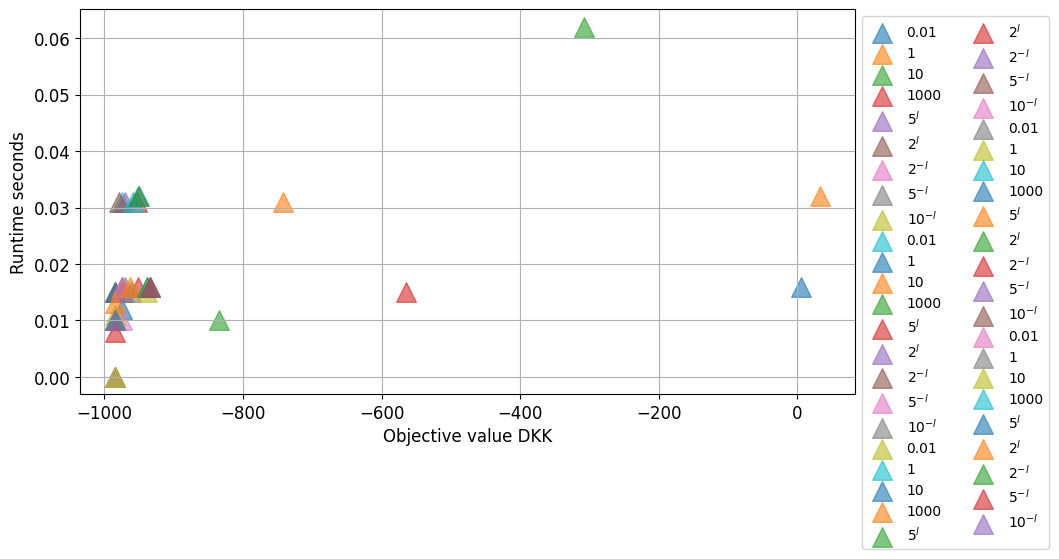

In [17]:
best_cases = []
for key, df in list(summary_tables.groupby(["methodology", "scenario_type", "case"]))[8: 9]:    
    plt.figure(figsize = (10, 5))
    i = 0
    for idx, row in df.iterrows():
        penalty = get_penalty_value(row["weights"])
        hyperparams = penalty
        plt.scatter(row['objective_value'], row['runtime'], label=hyperparams, alpha=0.6, zorder=1, marker="^", s=200)
        i = i + 1
    plt.legend(ncols=2, 
               bbox_to_anchor=(1, 1), loc='upper left'
              )
    plt.xlabel("Objective value DKK", fontsize="large")
    plt.ylabel("Runtime seconds", fontsize="large")
    plt.xticks(fontsize="large")
    plt.yticks(fontsize="large")
    plt.grid(zorder = 0)
    plt.show()

('1', 'Low_prices', 'PCAR')


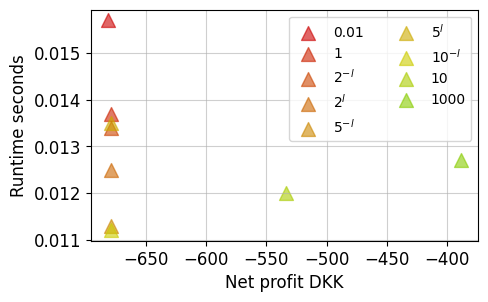

('1', 'Low_prices', 'PCTAR')


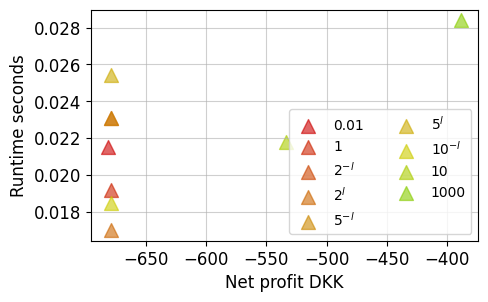

('2', 'Low_prices', 'PCAR')


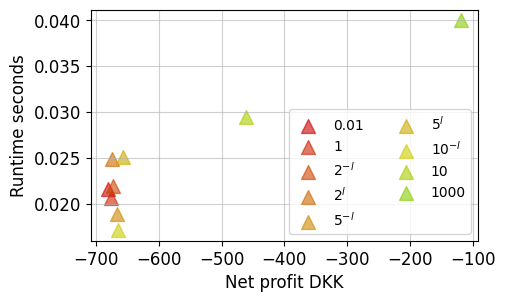

('2', 'Low_prices', 'PCTAR')


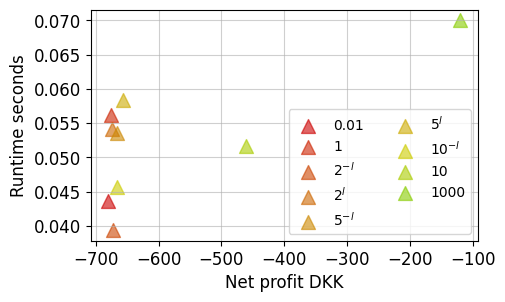

('4', 'Low_prices', 'PCAR')


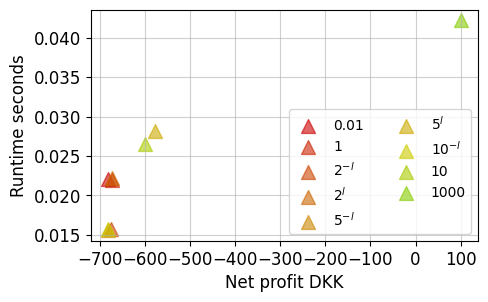

('4', 'Low_prices', 'PCTAR')


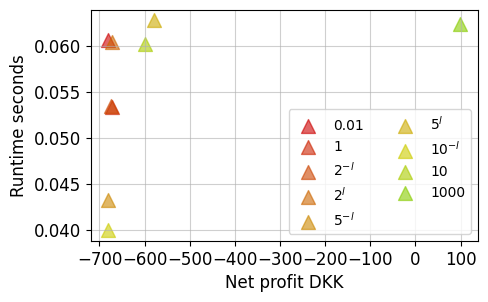

('5', 'Low_prices', 'PCAR')


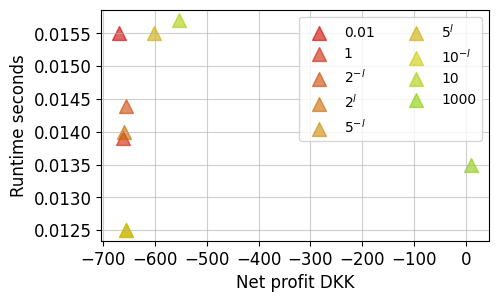

('5', 'Low_prices', 'PCTAR')


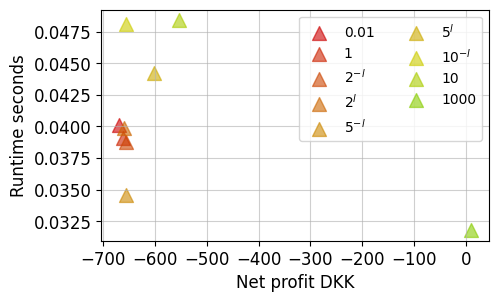

('6', 'Low_prices', 'PCAR')


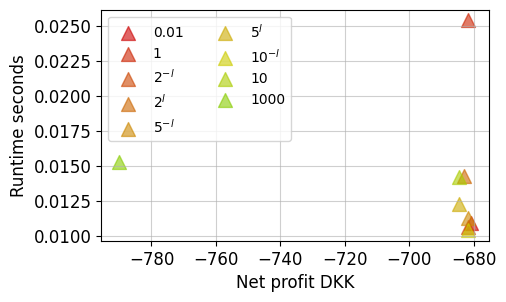

('6', 'Low_prices', 'PCTAR')


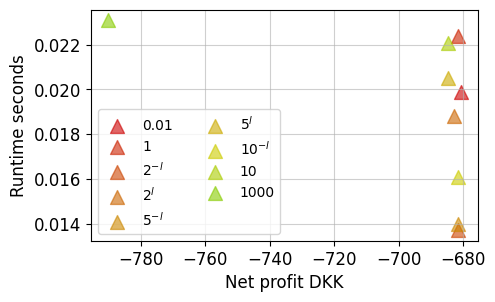

In [18]:
best_cases_dataframe = pd.DataFrame(columns=["length", "scenario_type", "methodology", "objective_value", "runtime", "best weight"])
for key, df in list(summary_tables.groupby(["length", "scenario_type", "methodology"])):
    print(key)
    plt.figure(figsize = (5, 3))
    i = 0
    grouped_df = df.groupby(["weights"])
    grouped_df = grouped_df[["objective_value", "runtime"]].mean().reset_index()
    grouped_df.runtime =  grouped_df.runtime.astype(float)
    best_case = identify_best_case(grouped_df)
    best_cases_dataframe.loc[len(best_cases_dataframe)] = [key[0], key[1], key[2], best_case.objective_value, best_case.runtime, best_case.weights]
    for idx, row in grouped_df.iterrows():
        penalty = get_penalty_value(row["weights"])
        hyperparams = penalty 
        plt.scatter(row['objective_value'], row['runtime'], label=hyperparams, alpha=0.6, zorder=1, marker="^", s=100, color=colors[i])
        i = i + 1
    plt.legend(ncols=2, fontsize="medium")
    plt.xlabel("Net profit DKK", fontsize="large")
    plt.ylabel("Runtime seconds", fontsize="large")
    plt.xticks(fontsize="large")
    plt.yticks(fontsize="large")
    # plt.ylim([0.02, 0.09])
    plt.grid(zorder=0, alpha=0.6)
    # plt.savefig(os.path.join(cwd, "images", "med_price_penalty_sensitivity.pdf"), bbox_inches="tight")
    plt.show()

In [19]:
df = best_cases_dataframe.groupby(["length", "methodology", "scenario_type"])[["best weight"]].sum()
latex_code = df.to_latex()
print(latex_code)

\begin{tabular}{llll}
\toprule
 &  &  & best weight \\
length & methodology & scenario_type &  \\
\midrule
\multirow[t]{2}{*}{1} & PCAR & Low_prices & (1000, 0) \\
\cline{2-4}
 & PCTAR & Low_prices & (1000, 0) \\
\cline{1-4} \cline{2-4}
\multirow[t]{2}{*}{2} & PCAR & Low_prices & (1000, 0) \\
\cline{2-4}
 & PCTAR & Low_prices & (1000, 0) \\
\cline{1-4} \cline{2-4}
\multirow[t]{2}{*}{4} & PCAR & Low_prices & (1000, 0) \\
\cline{2-4}
 & PCTAR & Low_prices & (1000, 0) \\
\cline{1-4} \cline{2-4}
\multirow[t]{2}{*}{5} & PCAR & Low_prices & (1000, 0) \\
\cline{2-4}
 & PCTAR & Low_prices & (1000, 0) \\
\cline{1-4} \cline{2-4}
\multirow[t]{2}{*}{6} & PCAR & Low_prices & (0.01, 0) \\
\cline{2-4}
 & PCTAR & Low_prices & (0.01, 0) \\
\cline{1-4} \cline{2-4}
\bottomrule
\end{tabular}

